# Assignment 2: Nearest neighbours and Decision Trees on UNSW-NB15 dataset

Darren Dube
BDatSci (Statistical Learning)
Stellenbosch, South Africa
27041123@sun.ac.za

## Imports and loading of data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import utils

In [3]:
features_df = pd.read_csv('features.csv')
network_traffic_df = pd.read_csv('networkTraffic.csv', na_values='?')
attack_df = pd.read_csv('attack_category_map.csv')

## EDA (identification of data quality issues)

In [4]:
# drop unique id column
network_traffic_df = network_traffic_df.drop(columns='id')

In [84]:
network_traffic_df

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,udp,NaN,INT,2,0,496,0,90909.090200,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,udp,NaN,INT,2,0,1762,0,125000.000300,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,udp,NaN,INT,2,0,1068,0,200000.005100,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,udp,NaN,INT,2,0,900,0,166666.660800,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,udp,NaN,INT,2,0,2126,0,100000.002500,254,...,2,1,3,0,0,0,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257668,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,24,13,24,0,0,0,24,24,0,9
257669,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,254,...,1,1,2,0,0,0,1,1,0,8
257670,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,3,13,0,0,0,3,12,0,9
257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,30,14,30,0,0,0,30,30,0,9


In [22]:
# store lists of numerical and categorical features

# fix issues in features_df
features_df.columns = features_df.columns.str.strip()
features_df['Name'] = features_df['Name'].str.lower()

is_numeric = lambda col: features_df[features_df['Name'] == col]['Type'].values in ['Float', 'Integer', 'integer']
numeric = [col for col in network_traffic_df.columns if is_numeric(col) and col != 'attack_cat']
categorical = [col for col in network_traffic_df.columns if col not in numeric and col != 'attack_cat']

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_94924/3234638332.py:7: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  is_numeric = lambda col: features_df[features_df['Name'] == col]['Type'].values in ['Float', 'Integer', 'integer']


In [6]:
# look through DQRs for numerical and categorical features and reassign some numerical features to categorical
# NOTE: after looking at the descriptions of the numeric features with low cardinality, they all seem
#  to be indeed numeric; could alternatively create a separate "ordinal" category, but will leave unchagned for now
utils.continuous_dqr(network_traffic_df[numeric])
wrongly_numeric = []

,Feature,Count,% Miss.,Card.,Min.,1st Qrt.,Mean,Median,3rd Qrt.,Max.,Std. Dev.
0,dur,257673,0.0,109945,0.0,0.000008,1.246715e+00,0.004285,6.857770e-01,5.999999e+01,5.974305e+00
1,spkts,257673,0.0,646,1.0,2.000000,1.977714e+01,4.000000,1.200000e+01,1.064600e+04,1.359472e+02
2,dpkts,257673,0.0,627,0.0,0.000000,1.851470e+01,2.000000,1.000000e+01,1.101800e+04,1.119860e+02
3,sbytes,257673,0.0,9382,24.0,114.000000,8.572952e+03,528.000000,1.362000e+03,1.435577e+07,1.737739e+05
4,dbytes,257673,0.0,8653,0.0,0.000000,1.438729e+04,178.000000,1.064000e+03,1.465753e+07,1.461993e+05
5,sttl,257673,0.0,13,0.0,62.000000,1.800009e+02,254.000000,2.540000e+02,2.550000e+02,1.024883e+02
6,dttl,257673,0.0,9,0.0,0.000000,8.475496e+01,29.000000,2.520000e+02,2.540000e+02,1.127621e+02
7,sload,257673,0.0,121356,0.0,12318.004880,7.060869e+07,743942.312500,8.000000e+07,5.988000e+09,1.857313e+08
8,dload,257673,0.0,116380,0.0,0.000000,6.582143e+05,1747.441284,2.210538e+04,2.242273e+07,2.412372e+06
9,sloss,257673,0.0,490,0.0,0.000000,4.889317e+00,0.000000,3.000000e+00,5.319000e+03,6.557495e+01


In [17]:
np.sort(network_traffic_df['swin'].unique())

array([  0,   5,  14,  31,  42,  43,  45,  52,  67,  87,  99, 103, 154,
       156, 167, 168, 172, 192, 202, 232, 245, 255])

In [19]:
# number of missing values for 'service' descriptive feature
network_traffic_df['service'].isna().sum()

141321

Text(0.5, 1.0, 'Correlation Heatmap of top 12 correlated features')

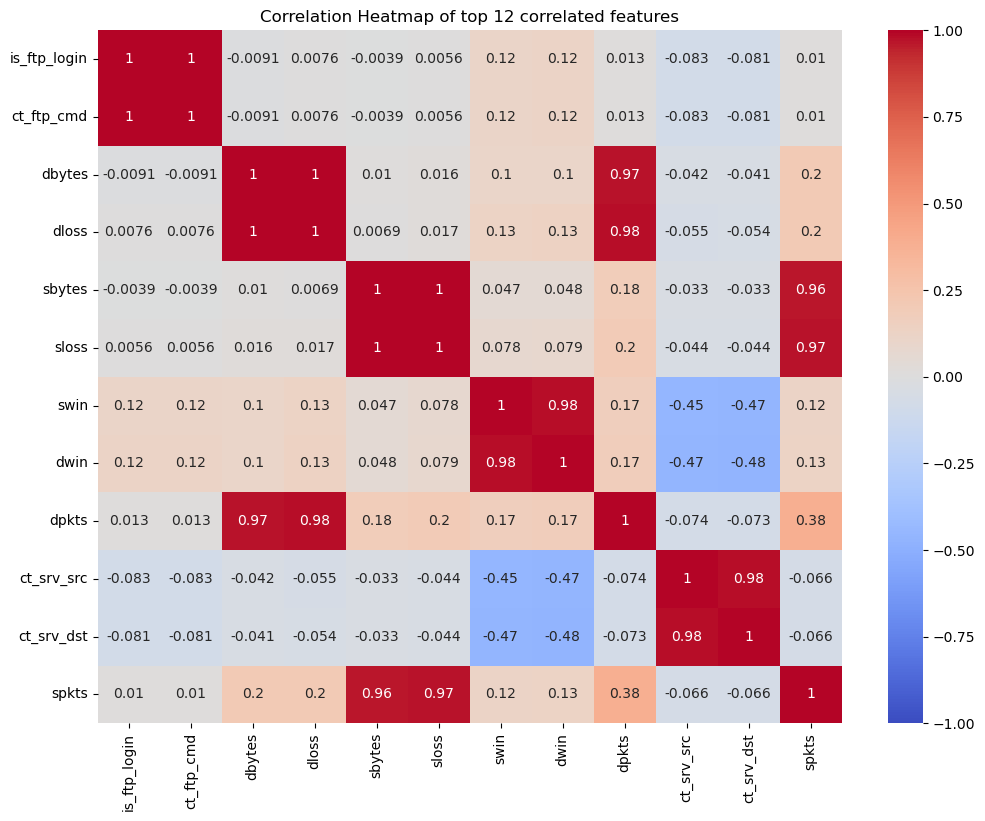

In [75]:
# compute correlation matrix for numerical features
corr_matrix = network_traffic_df.select_dtypes(include=["number"]).corr()
abs_corr = corr_matrix.abs()
top_features = (corr_matrix.abs() - np.eye(corr_matrix.shape[0])).max().nlargest(12).index
corr_matrix = corr_matrix.loc[top_features, top_features]
plt.figure(figsize=(12,9))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of top 12 correlated features')

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_94924/4090339572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=network_traffic_df, x='attack_cat', order=order, palette='crest', edgecolor="0.3").set_title('Class distribution of `attack_cat` target feature')


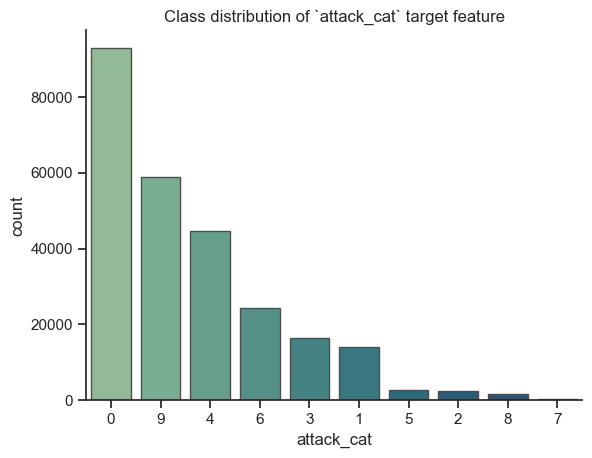

In [20]:
# class distribution of target feature
sns.set_theme(style='ticks')
order = network_traffic_df['attack_cat'].value_counts().index
ax = sns.countplot(data=network_traffic_df, x='attack_cat', order=order, palette='crest', edgecolor="0.3").set_title('Class distribution of `attack_cat` target feature')
sns.despine()

In [23]:
# outlier detection
# TODO: create a list of categorical features vs numerical (some categorical features are coded as numbers!)
count, count1 = 0, 0
for feature in network_traffic_df[numeric]:
    q1, q3 = network_traffic_df[feature].quantile([0.25, 0.75])
    outliers = network_traffic_df[(network_traffic_df[feature] < q1 - 1.5 * (q3 - q1)) | (network_traffic_df[feature] > q3 + 1.5 * (q3 - q1))]
    count1 += 1
    if not outliers.empty:
        print(f"Feature '{feature}' has {len(outliers)} outliers")
        count += 1


Feature 'dur' has 21597 outliers
Feature 'spkts' has 34871 outliers
Feature 'dpkts' has 29737 outliers
Feature 'sbytes' has 32164 outliers
Feature 'dbytes' has 40024 outliers
Feature 'sload' has 22034 outliers
Feature 'dload' has 57556 outliers
Feature 'sloss' has 16966 outliers
Feature 'dloss' has 39660 outliers
Feature 'sinpkt' has 20319 outliers
Feature 'dinpkt' has 17588 outliers
Feature 'sjit' has 23533 outliers
Feature 'djit' has 29010 outliers
Feature 'tcprtt' has 12442 outliers
Feature 'synack' has 21327 outliers
Feature 'ackdat' has 8557 outliers
Feature 'smean' has 32653 outliers
Feature 'dmean' has 33189 outliers
Feature 'trans_depth' has 25422 outliers
Feature 'response_body_len' has 16951 outliers
Feature 'ct_srv_src' has 28068 outliers
Feature 'ct_state_ttl' has 3763 outliers
Feature 'ct_dst_ltm' has 42388 outliers
Feature 'ct_src_dport_ltm' has 49014 outliers
Feature 'ct_dst_sport_ltm' has 48244 outliers
Feature 'ct_dst_src_ltm' has 43419 outliers
Feature 'ct_ftp_cmd' ha

In [25]:
len(numeric)

36

                   attack_cat
ct_dst_sport_ltm     0.700740
ct_src_dport_ltm     0.643166
ct_dst_src_ltm       0.628658
ct_srv_dst           0.612796
ct_srv_src           0.607888
ct_dst_ltm           0.576680
sttl                 0.567637
ct_src_ltm           0.544582
ct_state_ttl         0.460904
sload                0.151354
sbytes              -0.004332
response_body_len   -0.020875
sloss               -0.021527
sjit                -0.022497
dinpkt              -0.031583
ct_ftp_cmd          -0.037570
dur                 -0.039134
trans_depth         -0.047279
djit                -0.060888
spkts               -0.063487
dbytes              -0.063986
ct_flw_http_mthd    -0.066217
dloss               -0.080383
smean               -0.095276
dpkts               -0.104271
sinpkt              -0.123846
ackdat              -0.124137
synack              -0.129182
tcprtt              -0.136039
dttl                -0.191299
dload               -0.278020
dmean               -0.301663
dtcpb     

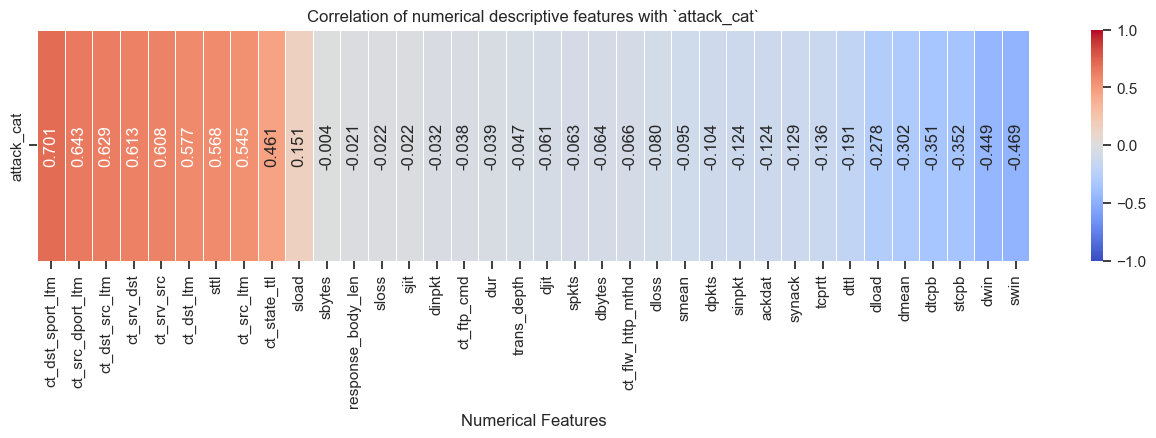

In [36]:
# detection of noise features by plotting correlation of each feature with the target
corr_matrix = network_traffic_df[numeric+['attack_cat']].corr()
target_corr = corr_matrix['attack_cat'].drop('attack_cat').sort_values(ascending=False).to_frame()
print(target_corr)

# 4. Generate a clean visual Heatmap Vector
plt.figure(figsize=(16, 3))
ax = sns.heatmap(
    target_corr.T,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt=".3f",
    linewidths=0.5,
)
for text in ax.texts: text.set_rotation(90)
plt.title('Correlation of numerical descriptive features with `attack_cat`')
plt.xlabel('Numerical Features')
plt.show()


## Data Preprocessing